# Task 01: Data acquisition basics

**Authors** :
- Borrelli, Emilio, mtk
- Pohlen, Eva, 1443363
- Hug, Victor, 2309471

Please put your code within the notebook python cells according to the template. 
The notebook is only used for questions requiring programming. If a question requires a screenshot or that you build a figure/sketch, this picture should be put within the report you submit. 

In [1]:
# list your required libraries
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import os
import scipy.io
import matplotlib.dates as mdates
from datetime import datetime, timedelta


## Usage of Biopac

In [2]:
# Question Q1
# Load the exp02 data of the biopac

exp1_biopac = scipy.io.loadmat('data/assignment_1/ECG_PPG_1.mat')
exp2_biopac = scipy.io.loadmat('data/assignment_1/ECG_PPG_2.mat')

In [3]:
ecg_1 = exp1_biopac['data'][:, 1]
ppg_1 = exp1_biopac['data'][:, 0]

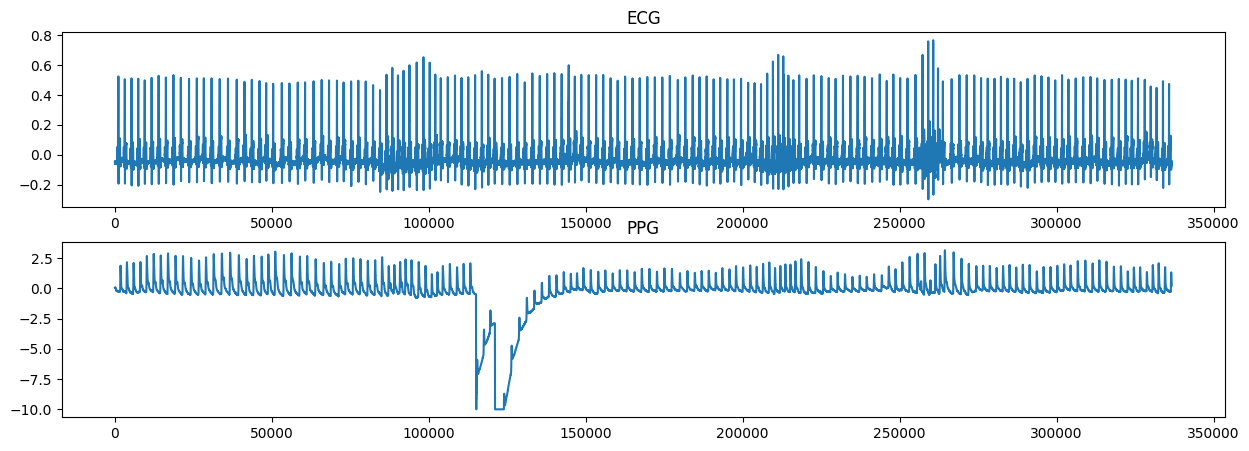

In [4]:
# Two Plots on top of each other with full curve
fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))
ax1.plot(ecg_1)
ax1.set_title('ECG')
ax2.plot(ppg_1)
ax2.set_title('PPG')
plt.show()

## Smartwatch

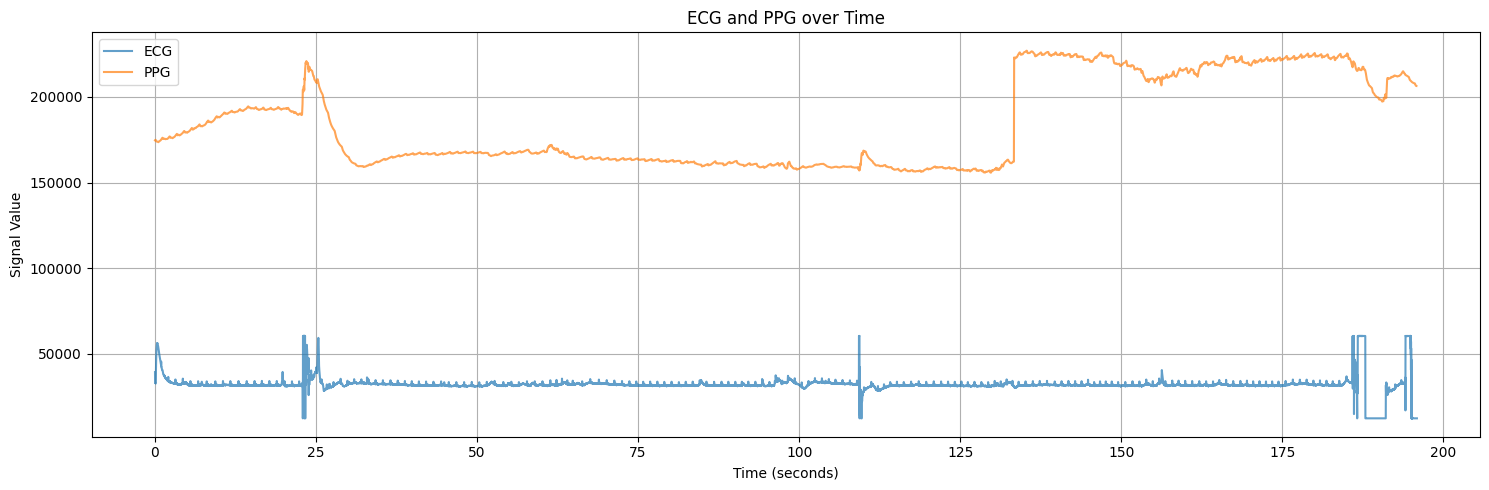

In [5]:
# Question Q3
ecg = pd.read_csv('data/assignment_2/ecg_2025_05_08_10_51_02ecgcentrifuge.csv', skiprows=2, engine='python')
ppg = pd.read_csv('data/assignment_2/ppg_2025_05_08_10_51_02ppgcentrifuge.csv', skiprows=2, engine='python')

# Clean Data
ecg.columns = ecg.columns.str.strip()
ppg.columns = ppg.columns.str.strip()
ecg = ecg[['Timestamp', 'ECG data']].dropna()
ppg = ppg[['PPG Timestamp', 'PPG']].dropna()

ecg['Timestamp'] = pd.to_numeric(ecg['Timestamp'], errors='coerce')
ecg['ECG data'] = pd.to_numeric(ecg['ECG data'], errors='coerce')
ppg['PPG Timestamp'] = pd.to_numeric(ppg['PPG Timestamp'], errors='coerce')
ppg['PPG'] = pd.to_numeric(ppg['PPG'], errors='coerce')

# Drop invalid rows
ecg = ecg.dropna()
ppg = ppg.dropna()

# Normalize timestamp
ecg['time_sec'] = (ecg['Timestamp'] - ecg['Timestamp'].iloc[0]) / 1000
ppg['time_sec'] = (ppg['PPG Timestamp'] - ppg['PPG Timestamp'].iloc[0]) / 1000

# Plot
plt.figure(figsize=(15, 5))

plt.plot(ecg['time_sec'], ecg['ECG data'], label='ECG', alpha=0.7)
plt.plot(ppg['time_sec'], ppg['PPG'], label='PPG', alpha=0.7)

plt.title("ECG and PPG over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



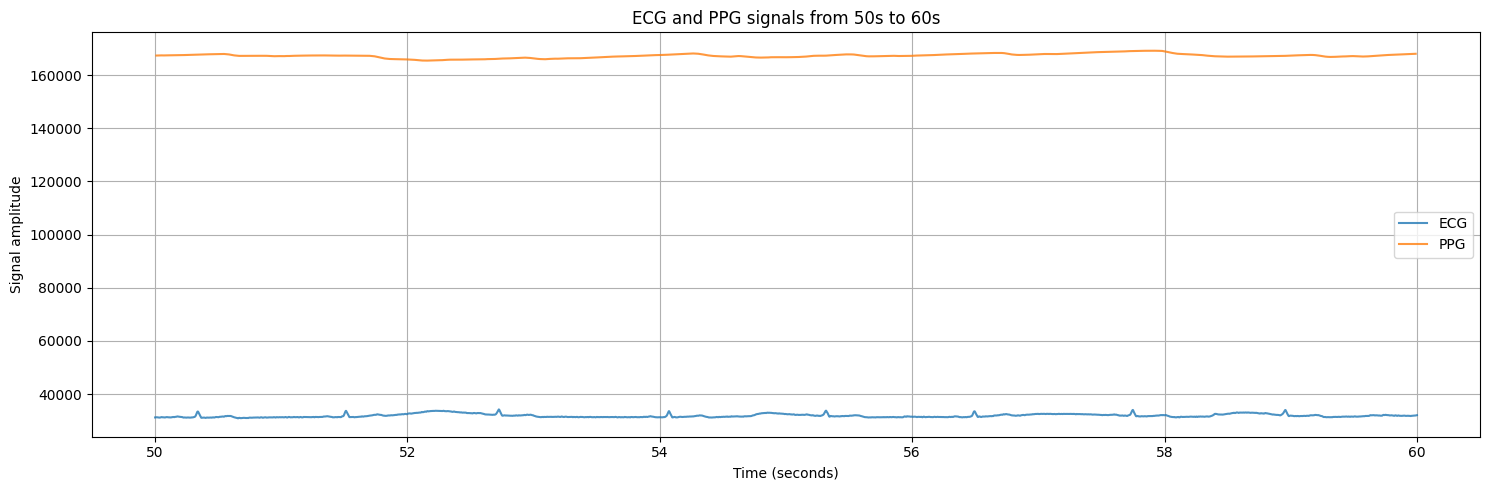

In [6]:
# Question Q4
# 1. Define time window manually (e.g., 20 to 30 seconds)
start_time = 50  # in seconds
end_time = 60    # 10 seconds later

# Filter both signals
ecg_window = ecg[(ecg['time_sec'] >= start_time) & (ecg['time_sec'] <= end_time)]
ppg_window = ppg[(ppg['time_sec'] >= start_time) & (ppg['time_sec'] <= end_time)]

# Plot
plt.figure(figsize=(15, 5))

plt.plot(ecg_window['time_sec'], ecg_window['ECG data'], label='ECG', alpha=0.8)
plt.plot(ppg_window['time_sec'], ppg_window['PPG'], label='PPG', alpha=0.8)

plt.title(f"ECG and PPG signals from {start_time}s to {end_time}s")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


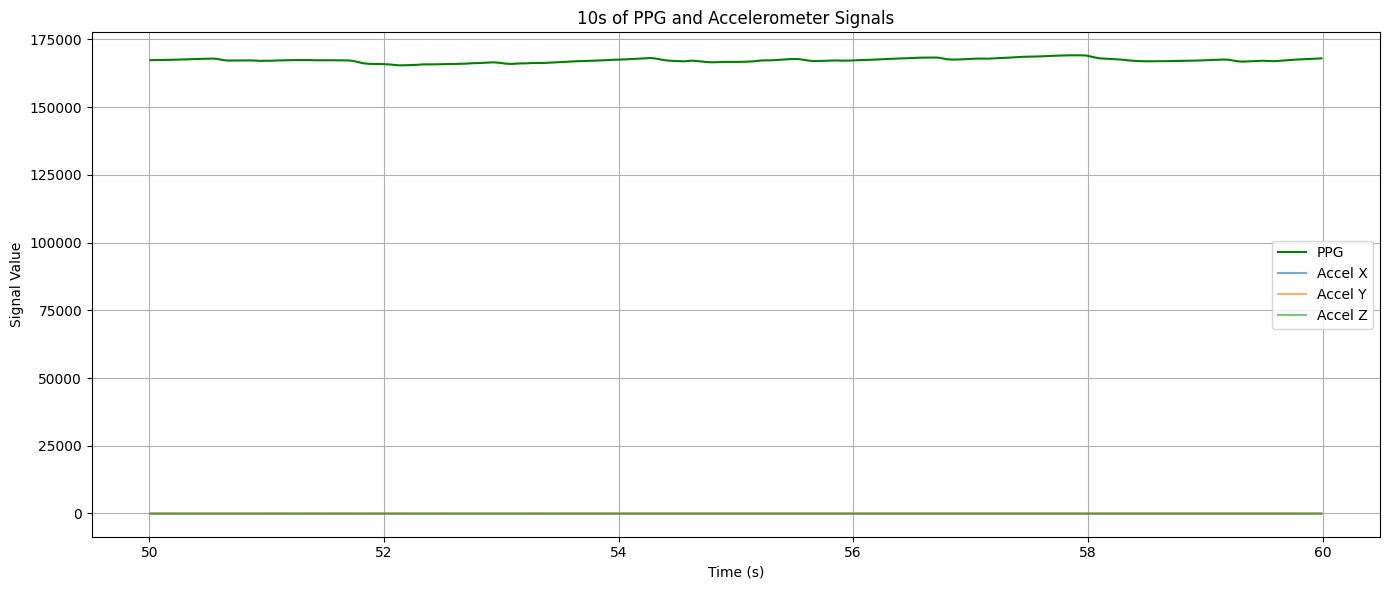

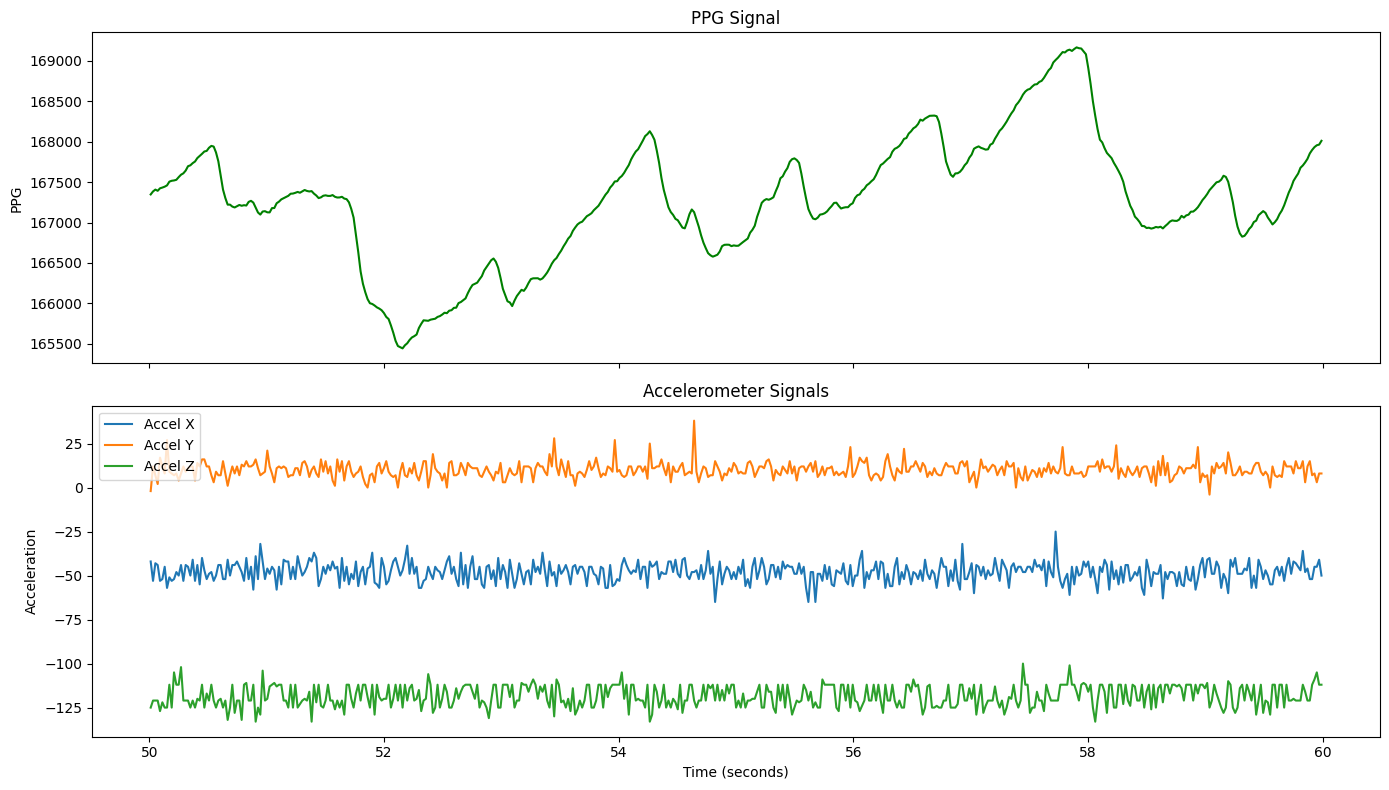

In [7]:
# Question Q5
df = pd.read_csv('data/assignment_2/ppg_2025_05_08_10_51_02ppgcentrifuge.csv', skiprows=2)

# Clean and convert
df = df[['PPG Timestamp', 'PPG', 'X', 'Y', 'Z']].dropna()
df['PPG Timestamp'] = pd.to_numeric(df['PPG Timestamp'], errors='coerce')
df = df.dropna()

# Convert to seconds
df['time_sec'] = (df['PPG Timestamp'] - df['PPG Timestamp'].iloc[0]) / 1000

# Select a 10s window (e.g., from 10s to 20s)
start = 50
end = start + 10
window = df[(df['time_sec'] >= start) & (df['time_sec'] <= end)]

# Plot PPG and accelerometer
plt.figure(figsize=(14, 6))

plt.plot(window['time_sec'], window['PPG'], label='PPG', color='green')
plt.plot(window['time_sec'], window['X'], label='Accel X', alpha=0.6)
plt.plot(window['time_sec'], window['Y'], label='Accel Y', alpha=0.6)
plt.plot(window['time_sec'], window['Z'], label='Accel Z', alpha=0.6)

plt.title("10s of PPG and Accelerometer Signals")
plt.xlabel("Time (s)")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Create figure and two vertically stacked subplots (shared x-axis)
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot PPG
axs[0].plot(window['time_sec'], window['PPG'], color='green')
axs[0].set_ylabel("PPG")
axs[0].set_title("PPG Signal")

# Plot Accelerometer X/Y/Z
axs[1].plot(window['time_sec'], window['X'], label='Accel X')
axs[1].plot(window['time_sec'], window['Y'], label='Accel Y')
axs[1].plot(window['time_sec'], window['Z'], label='Accel Z')
axs[1].set_ylabel("Acceleration")
axs[1].set_xlabel("Time (seconds)")
axs[1].set_title("Accelerometer Signals")
axs[1].legend()

plt.tight_layout()
plt.show()

Mean acceleration (approximate static gravity alignment):
X: -21.77 m/s²
Y: 14.60 m/s²
Z: -135.00 m/s²


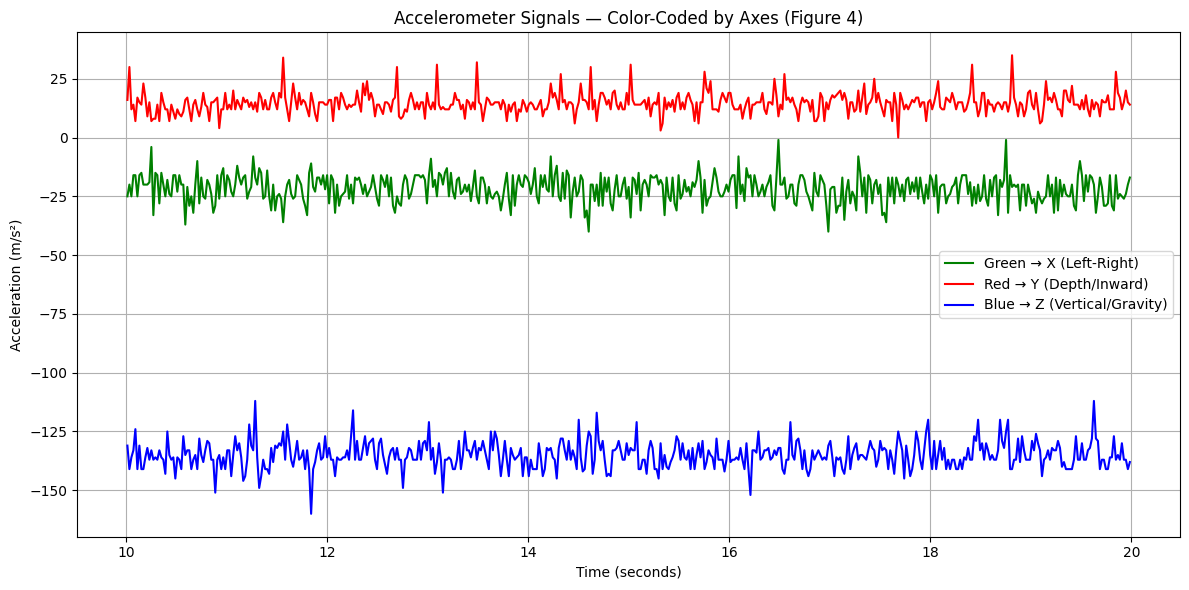

In [8]:
# Question Q6
# Load your data (adjust path if needed)
df = pd.read_csv('data/assignment_2/ppg_2025_05_08_10_51_02ppgcentrifuge.csv', skiprows=2)

# Keep only relevant columns
df = df[['PPG Timestamp', 'X', 'Y', 'Z']].dropna()

# Convert timestamp to seconds (relative)
df['PPG Timestamp'] = pd.to_numeric(df['PPG Timestamp'], errors='coerce')
df = df.dropna()
df['time_sec'] = (df['PPG Timestamp'] - df['PPG Timestamp'].iloc[0]) / 1000

# Select a 10-second still window (adjust as needed)
start = 10
end = 20
window = df[(df['time_sec'] >= start) & (df['time_sec'] <= end)]

# Calculate average acceleration on each axis
mean_x = window['X'].mean()
mean_y = window['Y'].mean()
mean_z = window['Z'].mean()

print("Mean acceleration (approximate static gravity alignment):")
print(f"X: {mean_x:.2f} m/s²")
print(f"Y: {mean_y:.2f} m/s²")
print(f"Z: {mean_z:.2f} m/s²")

# Plot axes with Figure 4's color coding:
# Green = horizontal (X), Red = depth (Y), Blue = vertical (Z)
plt.figure(figsize=(12, 6))

plt.plot(window['time_sec'], window['X'], color='green', label='Green → X (Left-Right)')
plt.plot(window['time_sec'], window['Y'], color='red', label='Red → Y (Depth/Inward)')
plt.plot(window['time_sec'], window['Z'], color='blue', label='Blue → Z (Vertical/Gravity)')

plt.title("Accelerometer Signals — Color-Coded by Axes (Figure 4)")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (m/s²)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Temporal synchronization

In [9]:
# Question Q7
# Load the data which includes watch and biopac
exp2_biopac = scipy.io.loadmat('data/assignment_1/ECG_PPG_2.mat')

def load_watch_ppg(filename):
    df = pd.read_csv(filename, skiprows=2)
    df = df[['PPG Timestamp', 'PPG', 'X', 'Y', 'Z']].dropna()
    df['PPG Timestamp'] = pd.to_numeric(df['PPG Timestamp'], errors='coerce')
    df = df.dropna()

    # Convert to seconds
    df['time_sec'] = (df['PPG Timestamp'] - df['PPG Timestamp'].iloc[0]) / 1000
    return df

def load_watch_ecg(filename):
    df = pd.read_csv(filename, skiprows=2)
    df = df[['Timestamp', 'ECG data']].dropna()
    df['Timestamp'] = pd.to_numeric(df['Timestamp'], errors='coerce')
    df['ECG data'] = pd.to_numeric(df['ECG data'], errors='coerce')
    df = df.dropna()

    # Convert to seconds
    df['time_sec'] = (df['Timestamp'] - df['Timestamp'].iloc[0]) / 1000
    return df

exp2_watch_ecg = load_watch_ecg('data/assignment_1/ecg_watch_11_00_54.csv')
exp2_watch_ppg = load_watch_ppg('data/assignment_1/ppg_watch_11_00_54.csv')


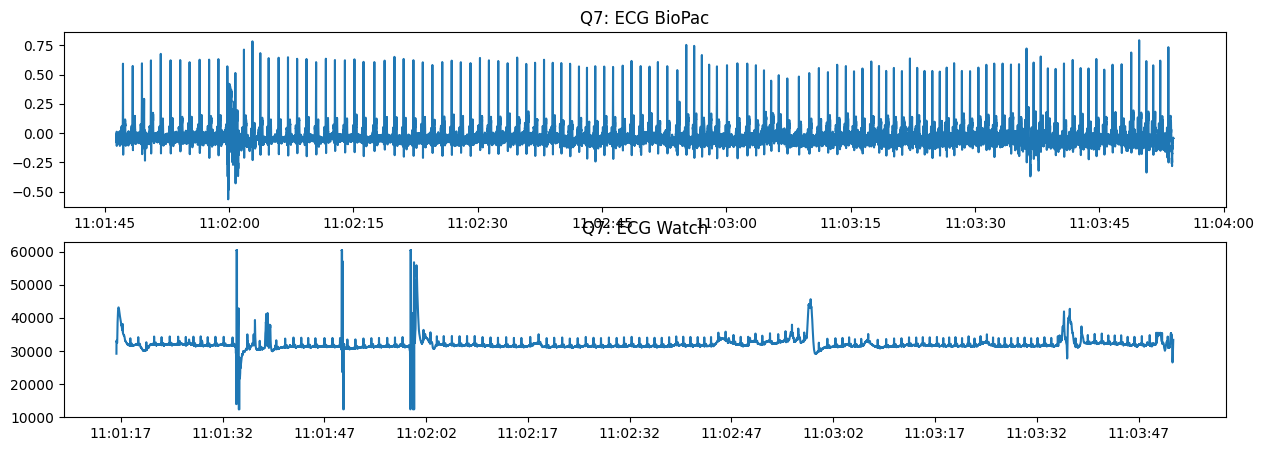

In [10]:
# Question Q8 ECG
# Exp2 Biopac Start Datetime: 2025-05-08 11:01:46.417

start_time_exp2_biopac = datetime(2025, 5, 8, 11, 1, 46, 417000)

fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))

ax1.plot([start_time_exp2_biopac + timedelta(milliseconds=0.5) * i for i in range(len(exp2_biopac['data'][:, 1]))], exp2_biopac['data'][:, 1])
ax1.set_title('Q7: ECG BioPac')

ax2.plot([datetime.fromtimestamp(int(x)/1000) for x in exp2_watch_ecg['Timestamp']], exp2_watch_ecg['ECG data'])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax2.xaxis.set_major_locator(mdates.SecondLocator(interval=15))
ax2.set_title('Q7: ECG Watch')

plt.show()



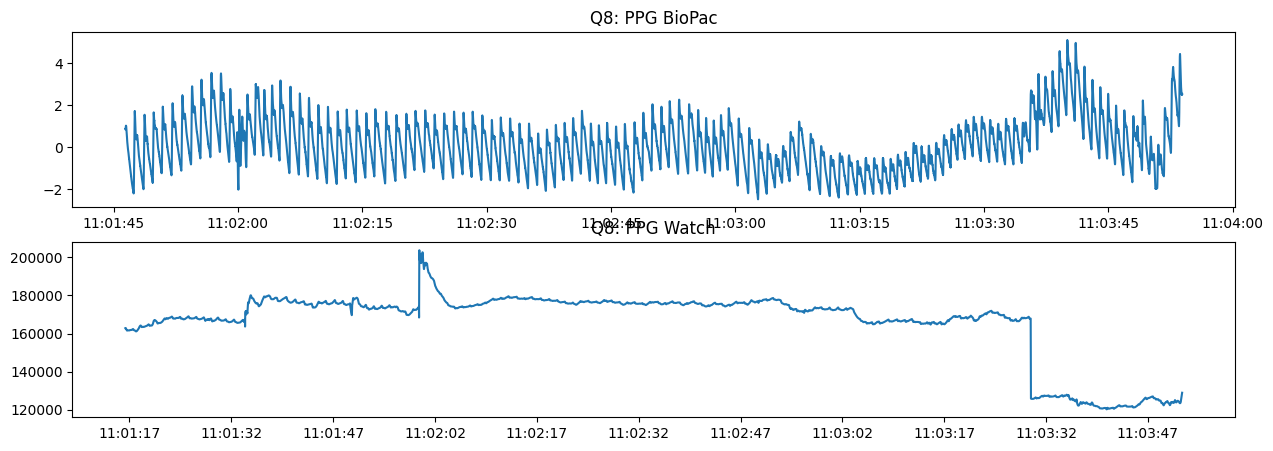

In [11]:
#Question Q8 PPG
start_time_exp2_biopac = datetime(2025, 5, 8, 11, 1, 46, 417000)

fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))

ax1.plot([start_time_exp2_biopac + timedelta(milliseconds=0.5) * i for i in range(len(exp2_biopac['data'][:, 0]))], exp2_biopac['data'][:, 0])
ax1.set_title('Q8: PPG BioPac')

ax2.plot([datetime.fromtimestamp(int(x)/1000) for x in exp2_watch_ppg['PPG Timestamp']], exp2_watch_ppg['PPG'])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax2.xaxis.set_major_locator(mdates.SecondLocator(interval=15))
ax2.set_title('Q8: PPG Watch')

plt.show()

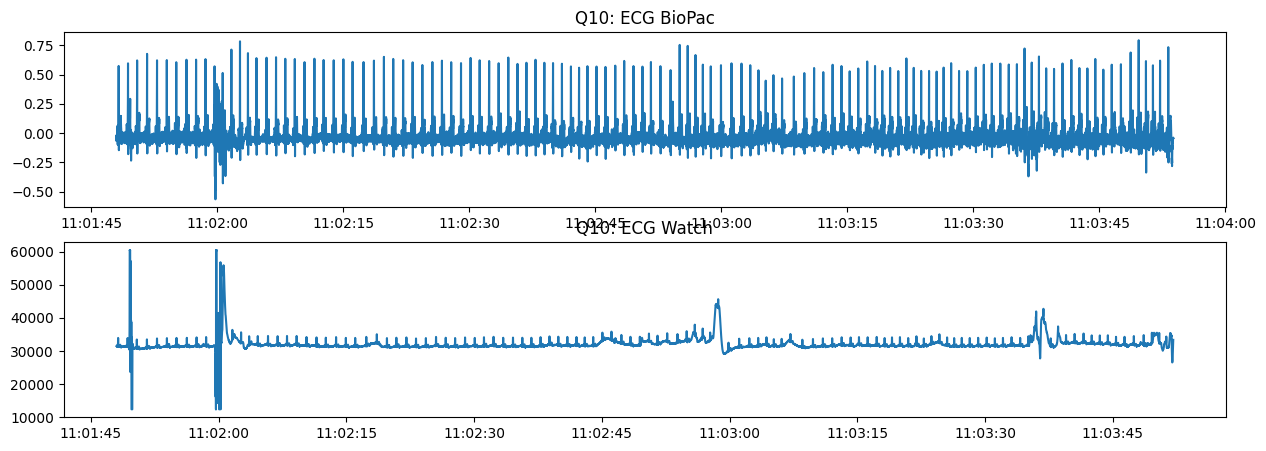

In [12]:
# Question Q10
# ECG Synced by Timestamp and Artifact Position

best_start_datetime = datetime(2025, 5, 8, 11, 1, 48)

fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))

biopac_ecg_data = [
    [best_start_datetime + timedelta(seconds=-1.7) + timedelta(milliseconds=0.5) * i,
     exp2_biopac['data'][i, 1]] for i in range(len(exp2_biopac['data'][:, 1]))
]

watch_ecg_data = [
    [datetime.fromtimestamp(int(exp2_watch_ecg['Timestamp'][i])/1000), exp2_watch_ecg['ECG data'][i]]
    for i in range(len(exp2_watch_ecg['Timestamp']))
]

watch_ecg_data = list(filter(lambda x: best_start_datetime <= x[0], watch_ecg_data))
biopac_ecg_data = list(filter(lambda x:  x[0] >= best_start_datetime, biopac_ecg_data))

ax1.plot([x[0] for x in biopac_ecg_data], [x[1] for x in biopac_ecg_data])
ax1.set_title('Q10: ECG BioPac')

ax2.plot([x[0] for x in watch_ecg_data], [x[1] for x in watch_ecg_data])
ax2.set_title('Q10: ECG Watch')
plt.show()

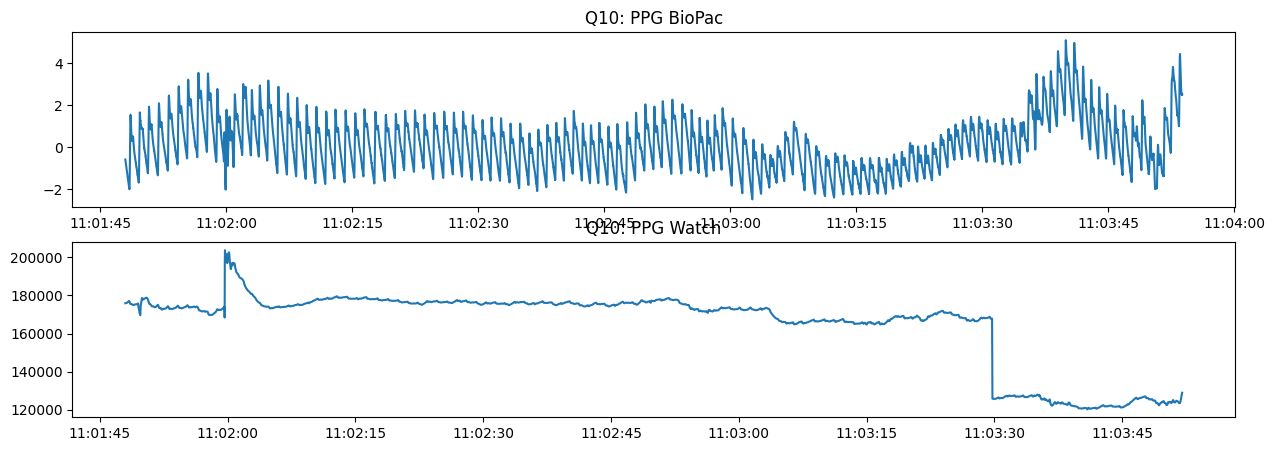

In [13]:
# Question Q10
# PPG Synced by Timestamp and Artifact Position

best_start_datetime = datetime(2025, 5, 8, 11, 1, 48)

fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))

biopac_ppg_data = [
    [best_start_datetime + timedelta(seconds=-1.7) + timedelta(milliseconds=0.5) * i,
     exp2_biopac['data'][i, 0]] for i in range(len(exp2_biopac['data'][:, 0]))
]

watch_ppg_data = [
    [datetime.fromtimestamp(int(exp2_watch_ppg['PPG Timestamp'][i])/1000), exp2_watch_ppg['PPG'][i]]
    for i in range(len(exp2_watch_ppg['PPG Timestamp']))
]

watch_ppg_data = list(filter(lambda x: best_start_datetime <= x[0], watch_ppg_data))
biopac_ppg_data = list(filter(lambda x:  x[0] >= best_start_datetime, biopac_ppg_data))

ax1.plot([x[0] for x in biopac_ppg_data], [x[1] for x in biopac_ppg_data])
ax1.set_title('Q10: PPG BioPac')

ax2.plot([x[0] for x in watch_ppg_data], [x[1] for x in watch_ppg_data])
ax2.set_title('Q10: PPG Watch')
plt.show()

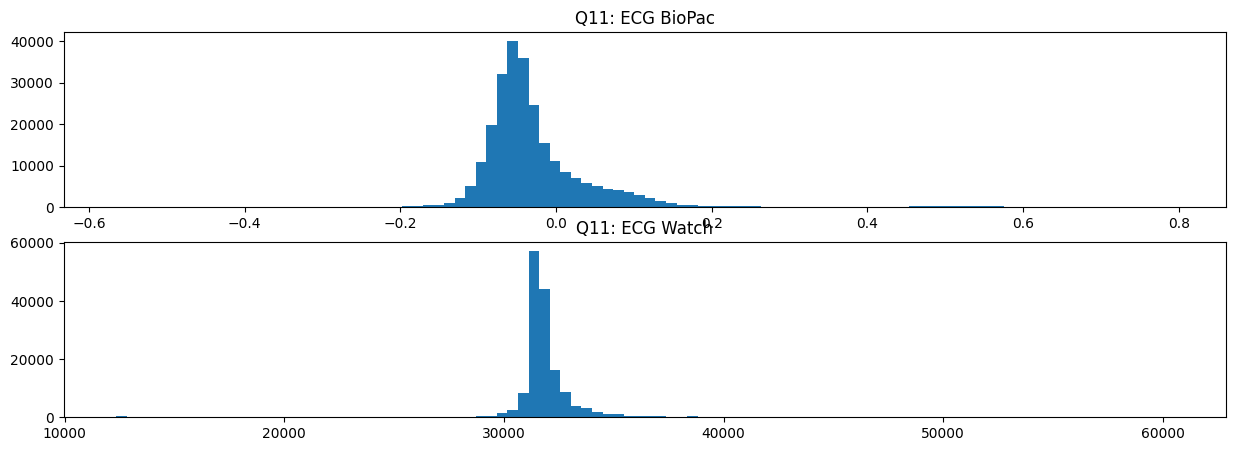

In [14]:
# Question Q11
# Histogram of ECG

fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))
ax1.hist( exp2_biopac['data'][:, 1], bins=100)
ax1.set_title('Q11: ECG BioPac')
ax2.hist(exp2_watch_ecg['ECG data'], bins=100)
ax2.set_title('Q11: ECG Watch')
plt.show()


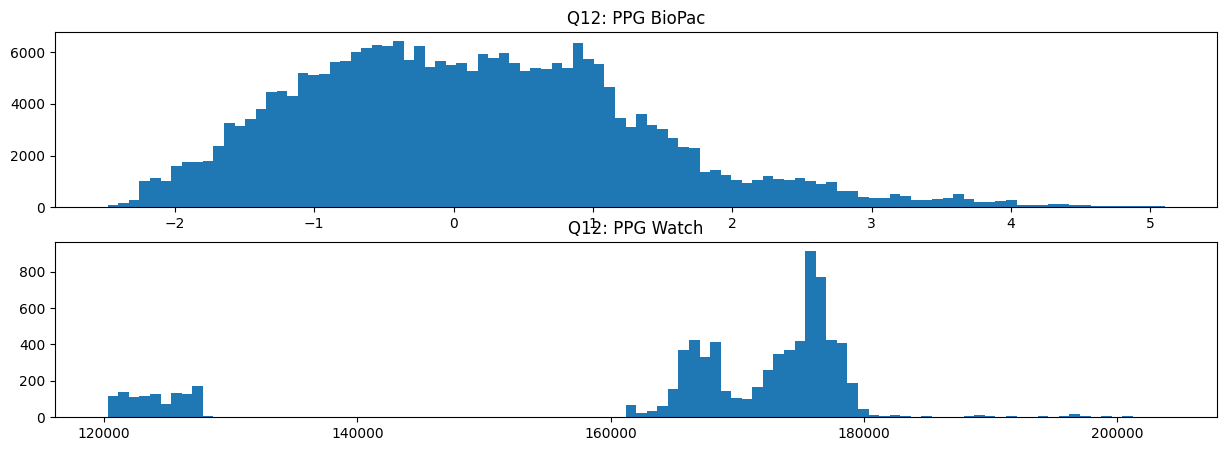

In [15]:
# Question Q12
# Histogram of PPG
fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))
ax1.hist( exp2_biopac['data'][:, 0], bins=100)
ax1.set_title('Q12: PPG BioPac')
ax2.hist(exp2_watch_ppg['PPG'], bins=100)
ax2.set_title('Q12: PPG Watch')
plt.show()